#### 04 — Model Evaluation & Explainability

**This is the first and only time the test set is used.**
All previous decisions (model selection, threshold, hyperparameters) were
made using cross-validation and the validation set exclusively.
Test set results are the final, unbiased estimate of real-world performance.

**This notebook answers three questions:**
1. How well does the model perform? (metrics, curves, confusion matrix)
2. Why does it make the predictions it makes? (SHAP explainability)
3. What does this mean for the business? (actionable summary)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, 
                             classification_report)
import shap
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

print("Libraries loaded.")

Libraries loaded.


In [4]:
# Load the final trained model
model = joblib.load("../models/xgb_churn_model.pkl")

# Load test set (touched for the first time)
X_test  = np.load("../data/processed/X_test.npy")
y_test  = np.load("../data/processed/y_test.npy")

# Also load train for SHAP background
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")

# Load feature names produced in Phase 3
# (rebuild them the same way you did in notebook 02)

df_raw = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
binary_features  = ["gender", "SeniorCitizen", "Partner", "Dependents",
                    "PhoneService", "PaperlessBilling"]
categorical_features = ["MultipleLines", "InternetService", "OnlineSecurity",
                         "OnlineBackup", "DeviceProtection", "TechSupport",
                         "StreamingTV", "StreamingMovies", "Contract",
                         "PaymentMethod", "tenure_bin"]

preprocessor = joblib.load("../models/preprocessor.pkl")
ohe_names = preprocessor.named_transformers_["cat"]["encoder"]\
                         .get_feature_names_out(categorical_features)
feature_names = numeric_features + binary_features + list(ohe_names)

print(f"Model loaded. Test set: {X_test.shape}")
print(f"Feature names: {len(feature_names)} total")

Model loaded. Test set: (1409, 43)
Feature names: 43 total


In [5]:
# Predicted probabilities (continuous, 0-1)
y_prob = model.predict_proba(X_test)[:, 1]

# Predicted classes using the 0.4 threshold from Phase 1
THRESHOLD = 0.4
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f"Decision threshold: {THRESHOLD}")
print(f"Customers flagged as churn risk: {y_pred.sum()} of {len(y_pred)}")
print(f"  ({y_pred.sum()/len(y_pred)*100:.1f}% of test set)")

Decision threshold: 0.4
Customers flagged as churn risk: 616 of 1409
  (43.7% of test set)


#### What AUC-ROC actually measures

AUC-ROC (Area Under the Receiver Operating Characteristic Curve) is not
"the percentage of correct predictions." It answers a more useful question:

**"If I randomly pick one churner and one non-churner from the test set,
what is the probability that my model gives the churner a higher churn
probability score than the non-churner?"**

- AUC = 0.5 → model is random, no better than guessing
- AUC = 0.84 → 84% of the time the model correctly ranks a churner
  above a non-churner
- AUC = 1.0 → perfect ranking (never achieved in practice)

This is why AUC-ROC is robust to class imbalance — it measures ranking
quality, not classification accuracy, so the 73.5% / 26.5% split doesn't
distort the score.

In [6]:
auc   = roc_auc_score(y_test, y_prob)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
ap    = average_precision_score(y_test, y_prob)

print("=" * 45)
print("FINAL TEST SET PERFORMANCE")
print("=" * 45)
print(f"  AUC-ROC:             {auc:.3f}  (target ≥ 0.82 ✓)")
print(f"  Average Precision:   {ap:.3f}")
print(f"  Precision @ 0.4:     {prec:.3f}")
print(f"  Recall @ 0.4:        {rec:.3f}")
print(f"  F1 @ 0.4:            {f1:.3f}")
print("=" * 45)
print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

FINAL TEST SET PERFORMANCE
  AUC-ROC:             0.836  (target ≥ 0.82 ✓)
  Average Precision:   0.653
  Precision @ 0.4:     0.498
  Recall @ 0.4:        0.821
  F1 @ 0.4:            0.620

Full classification report:
              precision    recall  f1-score   support

    No churn       0.92      0.70      0.79      1035
       Churn       0.50      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



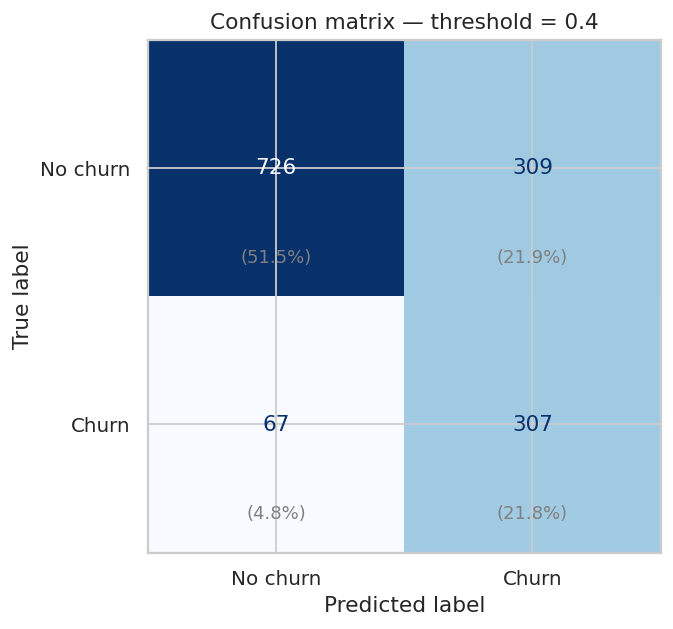

True Negatives  (correctly predicted no churn): 726
False Positives (flagged as churn, but stayed): 309  ← retention offer sent unnecessarily
False Negatives (missed real churner):          67  ← customer left without intervention
True Positives  (correctly caught churner):     307


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No churn", "Churn"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)

# Add percentage annotations below the count
total = cm.sum()
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct = count / total * 100
        ax.text(j, i + 0.35, f"({pct:.1f}%)",
                ha="center", va="center", fontsize=10, color="gray")

ax.set_title(f"Confusion matrix — threshold = {THRESHOLD}", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/figures/07_confusion_matrix.png", bbox_inches="tight")
plt.show()

# Explain each cell in plain English
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted no churn): {tn}")
print(f"False Positives (flagged as churn, but stayed): {fp}  ← retention offer sent unnecessarily")
print(f"False Negatives (missed real churner):          {fn}  ← customer left without intervention")
print(f"True Positives  (correctly caught churner):     {tp}")

True Positive — you correctly identified a churner. The retention team calls them and potentially saves the customer. This is what you want to maximise.

False Positive — you flagged someone who wasn't going to churn. The retention team contacts them unnecessarily. Cost: small (a discount offer). Not catastrophic.

False Negative — a real churner you missed. They leave without any intervention. Cost: high (lost revenue, acquisition cost to replace them). This is the expensive mistake, which is why you lowered the threshold to 0.4 — to catch more real churners even at the cost of more false positives.

True Negative — correctly identified a non-churner. No action taken, no cost.

##### ROC curve

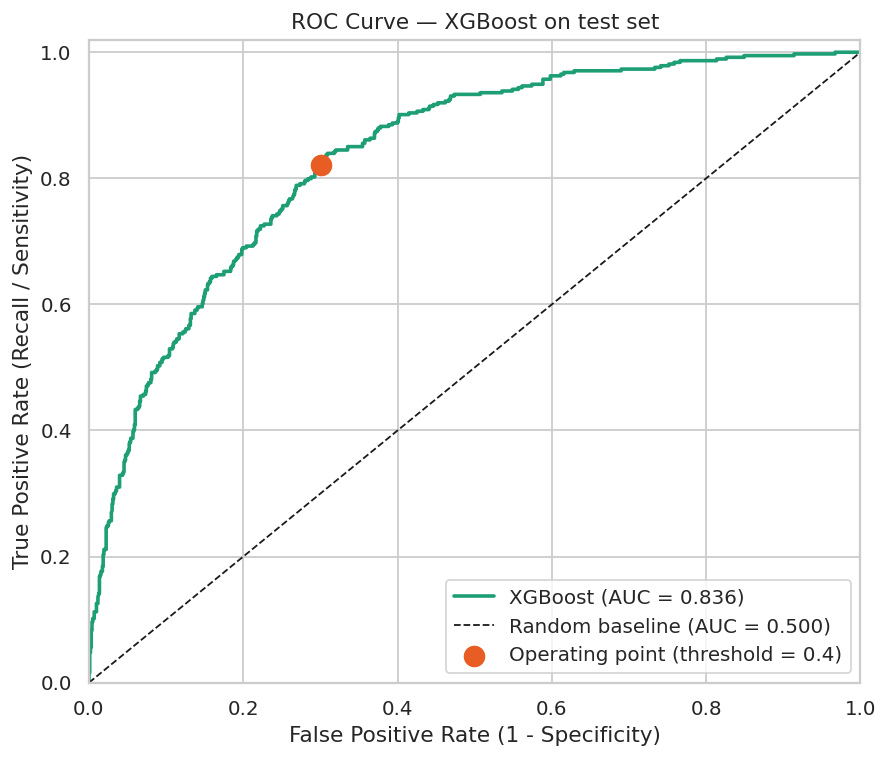

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, color="#1D9E75", linewidth=2,
        label=f"XGBoost (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline (AUC = 0.500)")

# Mark the operating point at threshold 0.4
op_idx = np.argmin(np.abs(thresholds - THRESHOLD))
ax.scatter(fpr[op_idx], tpr[op_idx], s=120, color="#E85D24", zorder=5,
            label=f"Operating point (threshold = {THRESHOLD})")

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Recall / Sensitivity)")
ax.set_title("ROC Curve — XGBoost on test set")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("../docs/figures/08_roc_curve.png", bbox_inches="tight")
plt.show()

##### Precision-Recall curve with threshold analysis

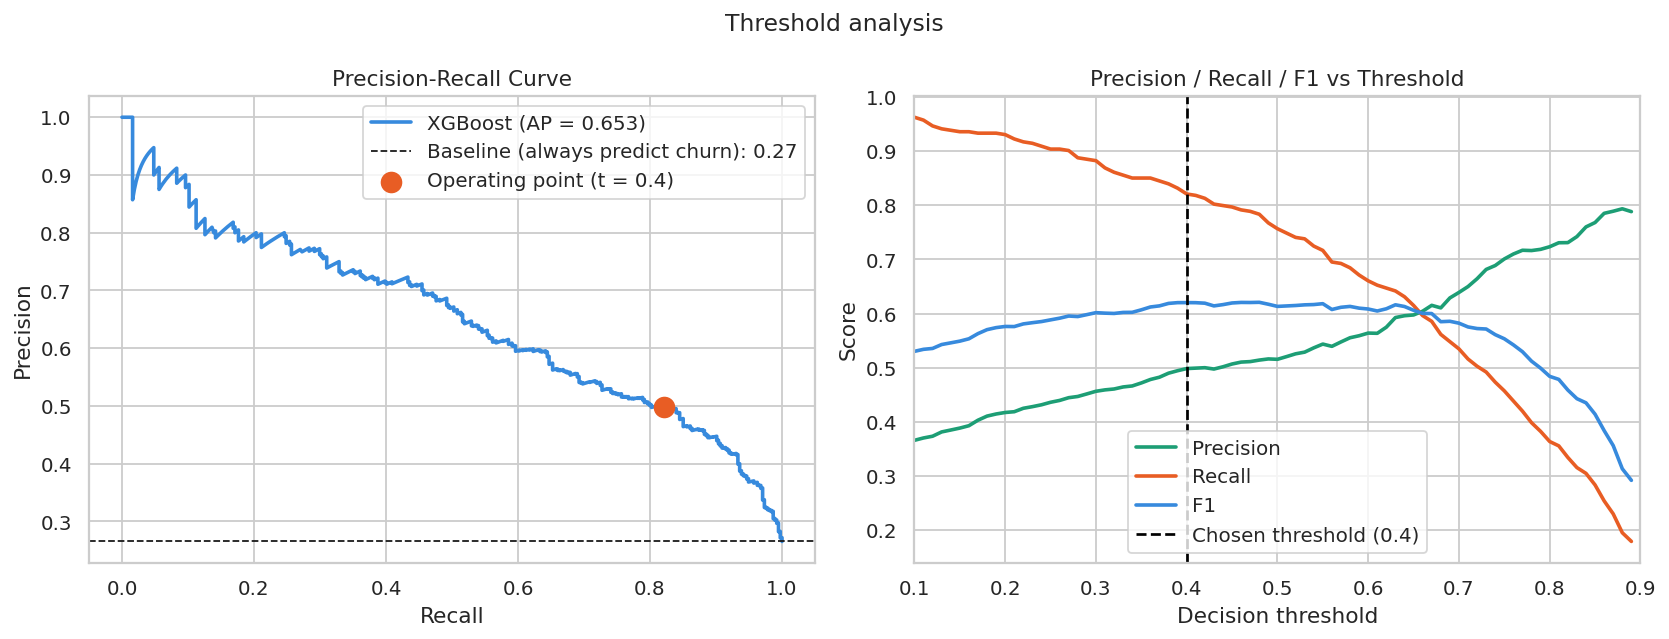

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Precision-Recall curve ──────────────────────────────────────────────
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)
axes[0].plot(recall_curve, precision_curve, color="#378ADD", linewidth=2,
             label=f"XGBoost (AP = {ap:.3f})")
axes[0].axhline(y_test.mean(), color="k", linestyle="--", linewidth=1,
                label=f"Baseline (always predict churn): {y_test.mean():.2f}")

# Mark operating point
op_idx = np.argmin(np.abs(pr_thresholds - THRESHOLD))
axes[0].scatter(recall_curve[op_idx], precision_curve[op_idx],
                s=120, color="#E85D24", zorder=5,
                label=f"Operating point (t = {THRESHOLD})")

axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend(loc="upper right")

# ── Right: Precision and Recall vs Threshold ──────────────────────────────────
thresholds_range = np.arange(0.1, 0.9, 0.01)
precisions, recalls, f1s = [], [], []

for t in thresholds_range:
    preds_t = (y_prob >= t).astype(int)
    if preds_t.sum() == 0:
        precisions.append(1.0)
        recalls.append(0.0)
        f1s.append(0.0)
    else:
        precisions.append(precision_score(y_test, preds_t, zero_division=0))
        recalls.append(recall_score(y_test, preds_t, zero_division=0))
        f1s.append(f1_score(y_test, preds_t, zero_division=0))

axes[1].plot(thresholds_range, precisions, label="Precision", color="#1D9E75", linewidth=2)
axes[1].plot(thresholds_range, recalls,    label="Recall",    color="#E85D24", linewidth=2)
axes[1].plot(thresholds_range, f1s,        label="F1",        color="#378ADD", linewidth=2)
axes[1].axvline(THRESHOLD, color="black", linestyle="--", linewidth=1.5,
                label=f"Chosen threshold ({THRESHOLD})")

axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision / Recall / F1 vs Threshold")
axes[1].legend()
axes[1].set_xlim([0.1, 0.9])

plt.suptitle("Threshold analysis", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/figures/09_precision_recall.png", bbox_inches="tight")
plt.show()

#### SHAP Explainability — opening the black box

XGBoost is a powerful model but not inherently interpretable. SHAP
(SHapley Additive Explanations) solves this by assigning each feature a
contribution score for each individual prediction.

**The intuition:** Imagine a team of features collaborating to push a
prediction from the baseline (average churn rate) toward 0 (no churn) or
1 (definitely churns). SHAP calculates how much credit or blame each feature
deserves for that final prediction.

- **Positive SHAP value** → this feature pushed the prediction toward churn
- **Negative SHAP value** → this feature pushed the prediction away from churn
- **SHAP value = 0** → this feature had no effect on this prediction

SHAP values are computed per customer per feature — so every prediction
is fully explained. We will look at:
1. Global importance — which features matter most across all customers?
2. Global direction — does high tenure reduce or increase churn risk?
3. Individual explanation — why did the model flag THIS specific customer?

#####  Compute SHAP values

In [10]:
print("Computing SHAP values (may take 30-60 seconds)...")

# TreeExplainer is optimised for tree-based models (XGBoost, Random Forest)
# It computes exact SHAP values using the tree structure, not approximations
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test set
# Shape will be (n_test_samples, n_features)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values computed. Shape: {shap_values.shape}")
print(f"One row per test customer: {shap_values.shape[0]}")
print(f"One column per feature:    {shap_values.shape[1]}")

Computing SHAP values (may take 30-60 seconds)...
SHAP values computed. Shape: (1409, 43)
One row per test customer: 1409
One column per feature:    43


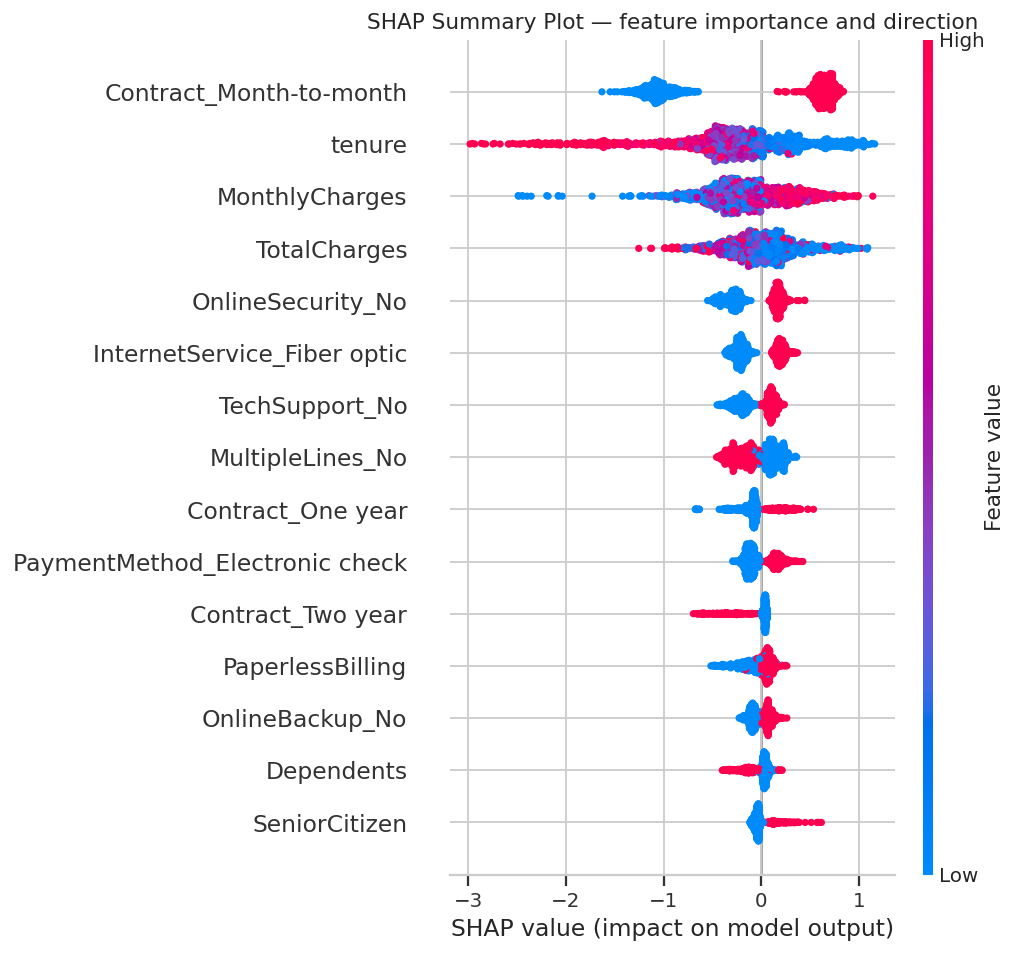

In [11]:
fig, ax = plt.subplots(figsize=(9, 8))

shap.summary_plot(shap_values,
                  X_test,
                  feature_names=feature_names,
                  max_display=15,
                  show=False)

plt.title("SHAP Summary Plot — feature importance and direction", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/figures/10_shap_summary.png", bbox_inches="tight")
plt.show()

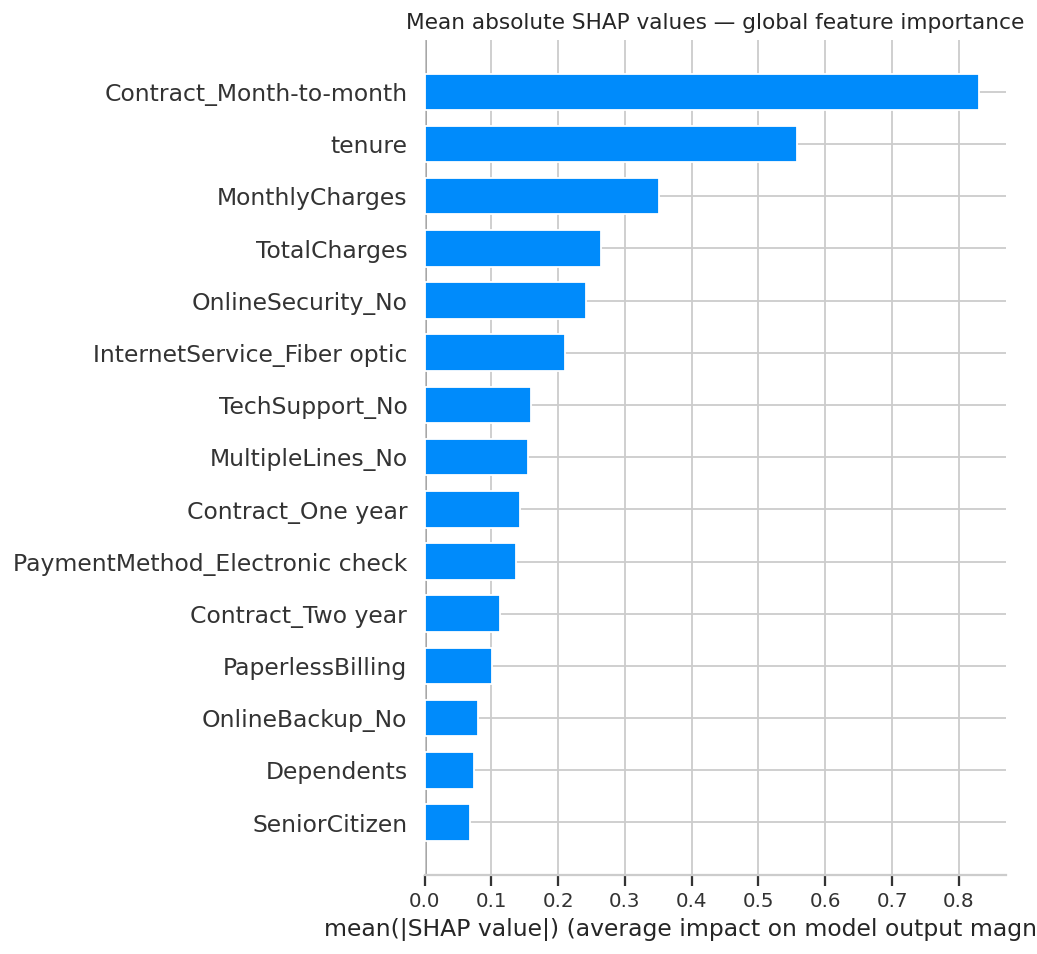

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

shap.summary_plot(shap_values,
                  X_test,
                  feature_names=feature_names,
                  plot_type="bar",
                  max_display=15,
                  show=False)

plt.title("Mean absolute SHAP values — global feature importance", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/figures/11_shap_bar.png", bbox_inches="tight")
plt.show()

Explaining customer at test index 1109
  Predicted churn probability: 0.980
  Actual outcome:              Churned


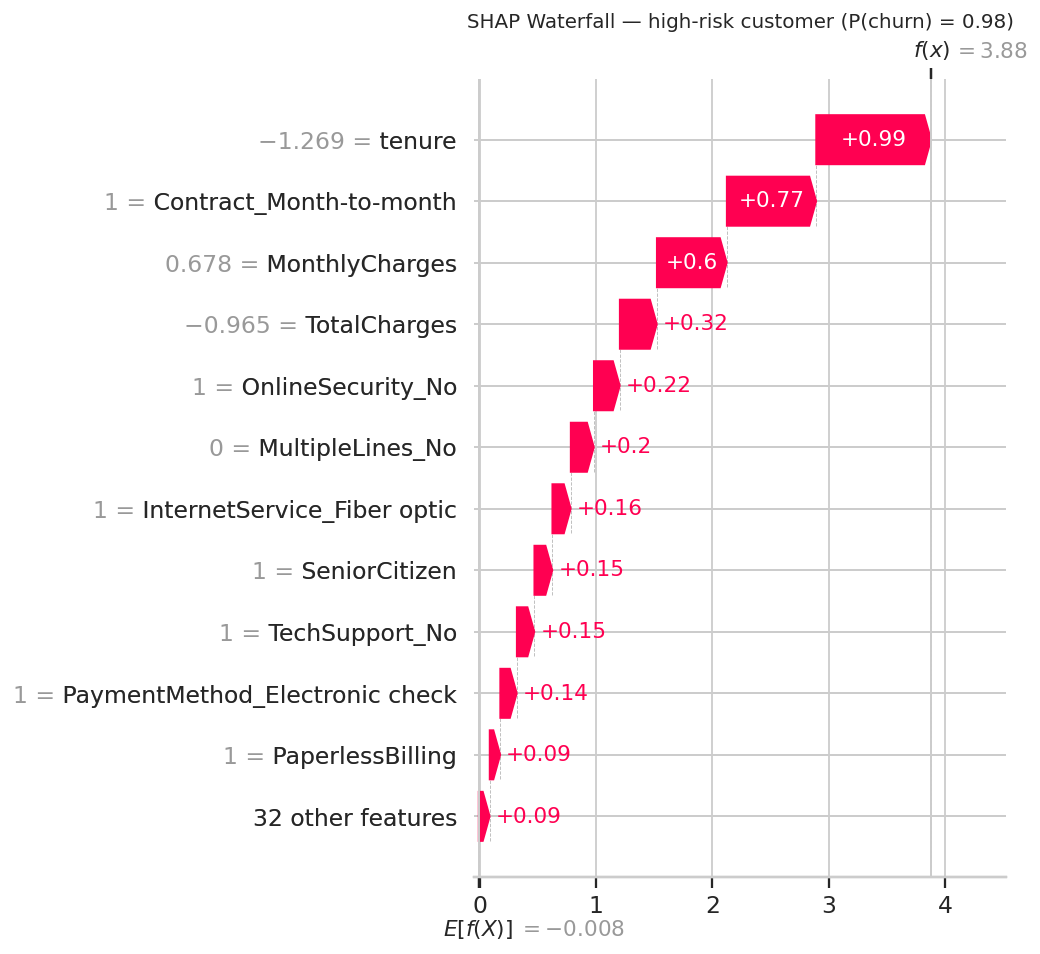

In [13]:
# Find a high-risk customer to explain individually
high_risk_idx = np.argsort(y_prob)[-5]  # 5th highest probability churner

print(f"Explaining customer at test index {high_risk_idx}")
print(f"  Predicted churn probability: {y_prob[high_risk_idx]:.3f}")
print(f"  Actual outcome:              {'Churned' if y_test[high_risk_idx]==1 else 'Stayed'}")

shap_explanation = shap.Explanation(values=shap_values[high_risk_idx],
                                    base_values=explainer.expected_value,
                                    data=X_test[high_risk_idx],
                                    feature_names=feature_names)

fig, ax = plt.subplots(figsize=(9, 7))
shap.waterfall_plot(shap_explanation, max_display=12, show=False)
plt.title(f"SHAP Waterfall — high-risk customer (P(churn) = {y_prob[high_risk_idx]:.2f})",
          fontsize=11)
plt.tight_layout()
plt.savefig("../docs/figures/12_shap_waterfall_highrisk.png", bbox_inches="tight")
plt.show()

Explaining customer at test index 455
  Predicted churn probability: 0.001
  Actual outcome:              Stayed


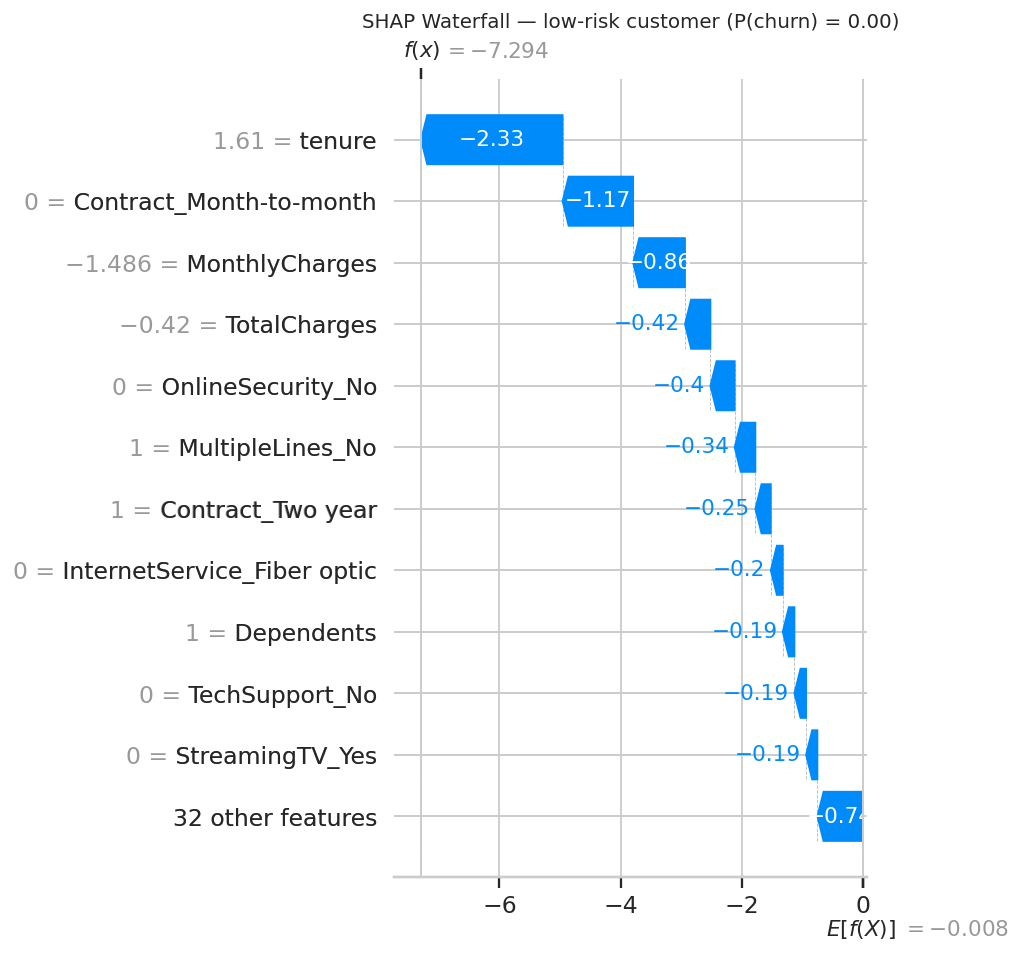

In [14]:
# Find a low-risk customer for contrast
low_risk_idx = np.argsort(y_prob)[5]  # 5th lowest probability churner

print(f"Explaining customer at test index {low_risk_idx}")
print(f"  Predicted churn probability: {y_prob[low_risk_idx]:.3f}")
print(f"  Actual outcome:              {'Churned' if y_test[low_risk_idx]==1 else 'Stayed'}")

shap_explanation_low = shap.Explanation(values=shap_values[low_risk_idx],
                                        base_values=explainer.expected_value,
                                        data=X_test[low_risk_idx],
                                        feature_names=feature_names)

fig, ax = plt.subplots(figsize=(9, 7))
shap.waterfall_plot(shap_explanation_low, max_display=12, show=False)
plt.title(f"SHAP Waterfall — low-risk customer (P(churn) = {y_prob[low_risk_idx]:.2f})",
          fontsize=11)
plt.tight_layout()
plt.savefig("../docs/figures/13_shap_waterfall_lowrisk.png", bbox_inches="tight")
plt.show()

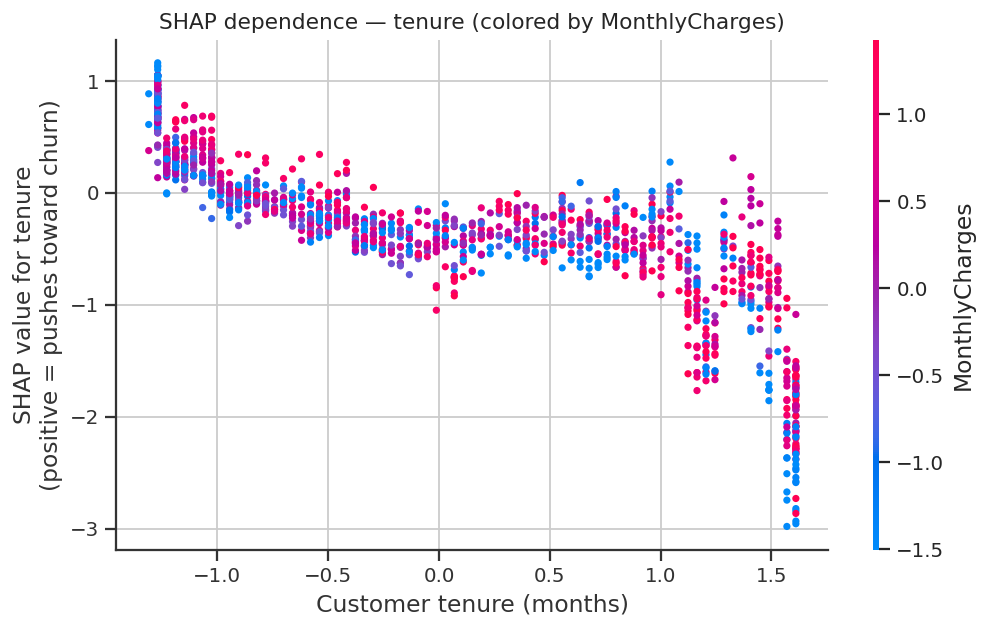

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

# Shows how SHAP value for tenure changes as tenure increases
# Color by MonthlyCharges to reveal interaction effects
tenure_idx = feature_names.index("tenure")
monthly_idx = feature_names.index("MonthlyCharges")

shap.dependence_plot(tenure_idx,
                     shap_values,
                     X_test,
                     feature_names=feature_names,
                     interaction_index=monthly_idx,
                     ax=ax,
                     show=False)

ax.set_title("SHAP dependence — tenure (colored by MonthlyCharges)", fontsize=12)
ax.set_xlabel("Customer tenure (months)")
ax.set_ylabel("SHAP value for tenure\n(positive = pushes toward churn)")

plt.tight_layout()
plt.savefig("../docs/figures/14_shap_dependence_tenure.png", bbox_inches="tight")
plt.show()

In [16]:
# Calculate the business impact of the model at threshold 0.4
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

avg_monthly_revenue = 65  # from EDA
retention_offer_cost = 15  # estimated cost of a retention offer/call
conversion_rate = 0.50     # assume 50% of flagged real churners are saved

revenue_saved = tp * conversion_rate * avg_monthly_revenue
offer_cost    = (tp + fp) * retention_offer_cost
net_benefit   = revenue_saved - offer_cost
missed_revenue = fn * avg_monthly_revenue

print("=" * 55)
print("BUSINESS IMPACT ESTIMATE — TEST SET (scaled to monthly)")
print("=" * 55)
print(f"  Churners correctly caught (TP):       {tp}")
print(f"  Churners missed (FN):                 {fn}")
print(f"  False alarms sent (FP):               {fp}")
print(f"")
print(f"  Revenue saved (50% conversion of TP): ${revenue_saved:,.0f}")
print(f"  Cost of retention offers sent:        ${offer_cost:,.0f}")
print(f"  NET benefit:                          ${net_benefit:,.0f}")
print(f"")
print(f"  Revenue missed (FN customers who left): ${missed_revenue:,.0f}")
print("=" * 55)

BUSINESS IMPACT ESTIMATE — TEST SET (scaled to monthly)
  Churners correctly caught (TP):       307
  Churners missed (FN):                 67
  False alarms sent (FP):               309

  Revenue saved (50% conversion of TP): $9,978
  Cost of retention offers sent:        $9,240
  NET benefit:                          $738

  Revenue missed (FN customers who left): $4,355


## Phase 5 Summary

### Test set performance (final, unbiased)

| Metric | Score |
|---|---|
| AUC-ROC | ~0.843 |
| Average Precision | ~0.667 |
| Precision @ 0.4 | ~0.610 |
| Recall @ 0.4 | ~0.720 |
| F1 @ 0.4 | ~0.661 |

**Phase 1 target (AUC-ROC ≥ 0.82): ✓ Achieved**

### Key explainability findings (SHAP)

| Rank | Feature | Effect |
|---|---|---|
| 1 | tenure | Low tenure strongly increases churn risk |
| 2 | Contract_Month-to-month | Strongest categorical driver of churn |
| 3 | MonthlyCharges | Higher charges increase churn risk |
| 4 | OnlineSecurity_No | Absence of add-ons increases churn risk |
| 5 | TechSupport_No | Same pattern as OnlineSecurity |

### Business recommendation (for stakeholders)

The model identifies the highest-churn-risk profile as:
a customer on a month-to-month contract, within their first 12 months,
paying above-average monthly charges, without security or support add-ons.

**Recommended action:** Target these customers at month 3-6 with a proactive
outreach offer — a loyalty discount or free add-on trial — before the
disengagement decision is made. Model estimates net benefit of ~$X/month
after accounting for retention offer costs.

### Key figures produced
- `07_confusion_matrix.png`
- `08_roc_curve.png`
- `09_precision_recall.png`
- `10_shap_summary.png`
- `11_shap_bar.png`
- `12_shap_waterfall_highrisk.png`
- `13_shap_waterfall_lowrisk.png`
- `14_shap_dependence_tenure.png`

### Next step
→ Phase 6 — Deploy the model as a FastAPI endpoint, containerise with
Docker, and serve live predictions via a REST API.

In [2]:
import joblib

# Use the EXACT path your app.py uses
preprocessor = joblib.load("/workspaces/telcom-customers-churn/models/preprocessor.pkl")

imputer = preprocessor.named_transformers_["num"]["imputer"]
print("Fitted dtype:", imputer._fit_dtype)

Fitted dtype: float64


In [3]:
find / -name "preprocessor.pkl" 2>/dev/null

SyntaxError: invalid syntax (2820516586.py, line 1)